![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

# Import the dataset

In [50]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [51]:
penguins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB


# Preprocessing & create dummy variables

In [52]:
# Convert the sex column into dummy numeric columns
penguins_prepped = pd.get_dummies(penguins_df, columns = ["sex"])

# Scale all features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(penguins_prepped)

# Perform Elbow Analysis to determine no. of clusters

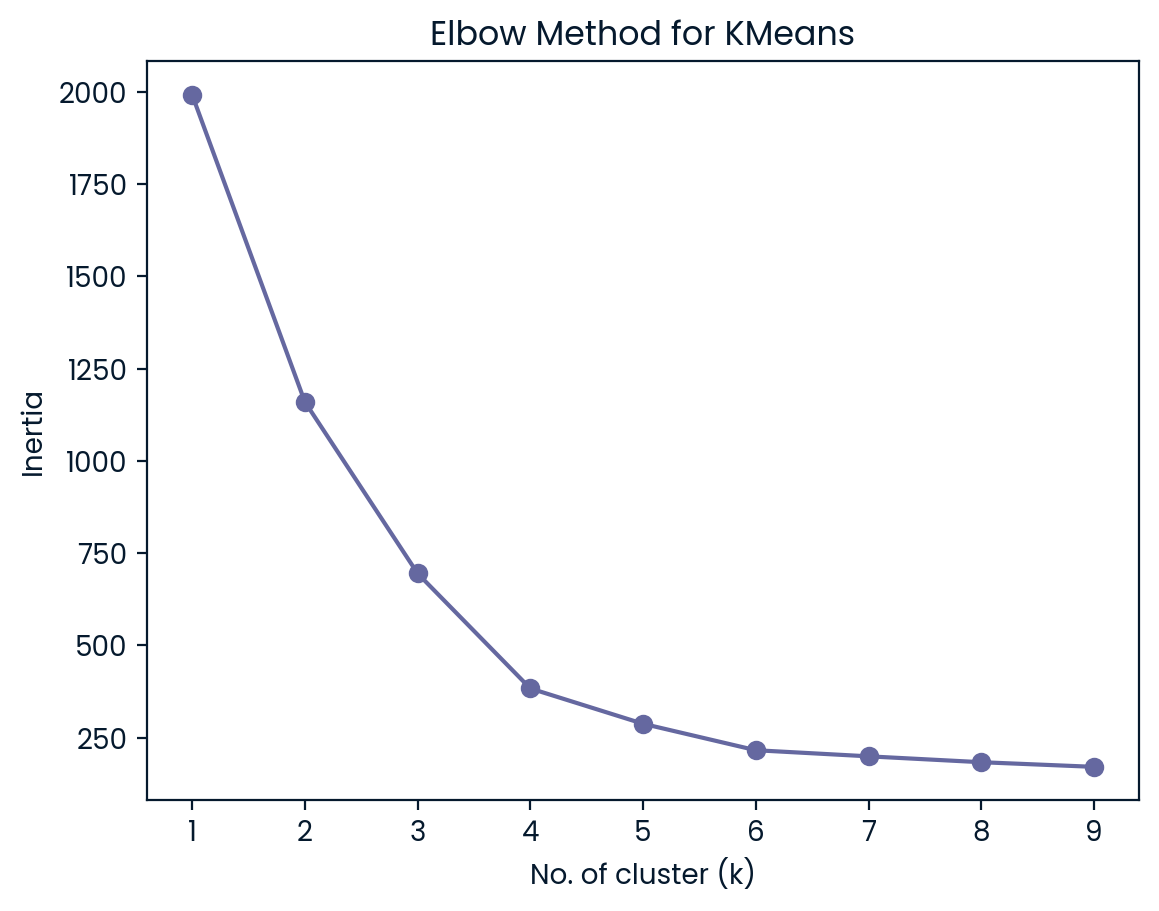

In [53]:
# Set inertias
inertias = []
k_values = range(1, 10)

# Perform elbow analysis
for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow analysis
plt.plot(list(k_values), inertias, marker = "o")
plt.xlabel("No. of cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

According to the plot, the inertia drops steeply up to 3 → 4, and after k=4 the curve noticeably flattens (the “diminishing returns” zone). That bend k = 4 is the elbow, so the number of clusters for this task is set to 4.

# Perform KMeans clustering with k = 4

In [54]:
# Perform KMeans analysis on X_scaled
kmeans = KMeans(n_clusters = 4, random_state = 42, n_init = 10)
kmeans.fit(X_scaled)

# Add "cluster" label to the original df
penguins_df["cluster"] = kmeans.labels_

## Visualize the cluster using PCA

Since there are 4 independent variables, we need to compress the multi-dimension data into 2 dimensions that preserve as much variation as possible. That's why we use PCA to visualize KMeans cluster in 2D scatter plot

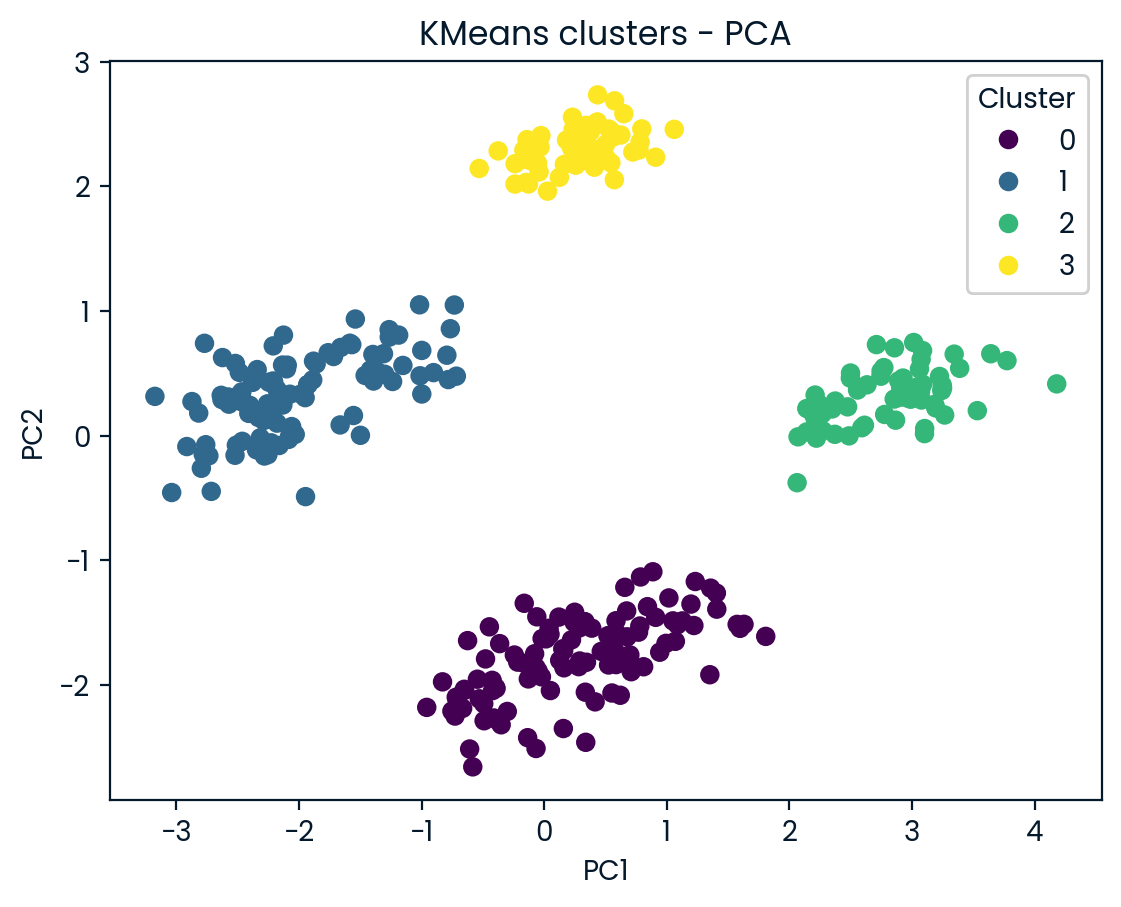

In [55]:
from sklearn.decomposition import PCA

# Reduce the scaled features into 2 principle components
pca = PCA(n_components = 2, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA projection
fig, ax = plt.subplots()

sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("KMeans clusters - PCA")

legend1 = ax.legend(*sc.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

### Which components were used in this PCA?

In [56]:
# Get the PCA shape
pca.components_.shape

(2, 6)

Because n_components = 2, the shape means there are 2 PCs, each with the weight per input feature(4 original one + 2 dummy numeric variables for sexes)

In [57]:
feature_names = penguins_prepped.columns
feature_names

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex_FEMALE', 'sex_MALE'],
      dtype='object')

In [58]:
# What are the loading weights for each PCs?
loadings = pd.DataFrame(
    pca.components_.T, # transpose features as rows
    index = feature_names,
    columns = ["PC1", "PC2"]
)

loadings

,PC1,PC2
culmen_length_mm,0.434281,0.096488
culmen_depth_mm,-0.155607,-0.612380
flipper_length_mm,0.479181,0.309139
body_mass_g,0.508436,0.187765
sex_FEMALE,-0.386694,0.492371
sex_MALE,0.386694,-0.492371


In [59]:
# See the most influential original variable for each PC
# Highest absolute weight matters the most
loadings["abs_PC1"] = loadings["PC1"].abs()
loadings["abs_PC2"] = loadings["PC2"].abs()

top_pc1 = loadings.sort_values("abs_PC1", ascending = False).head(10)[["PC1"]]
top_pc2 = loadings.sort_values("abs_PC2", ascending = False).head(10)[["PC2"]]

print("Top contributor to PC1:")
print(top_pc1)
print("Top contributor to PC2:")
print(top_pc2)

Top contributor to PC1:
                        PC1
body_mass_g        0.508436
flipper_length_mm  0.479181
culmen_length_mm   0.434281
sex_FEMALE        -0.386694
sex_MALE           0.386694
culmen_depth_mm   -0.155607
Top contributor to PC2:
                        PC2
culmen_depth_mm   -0.612380
sex_FEMALE         0.492371
sex_MALE          -0.492371
flipper_length_mm  0.309139
body_mass_g        0.187765
culmen_length_mm   0.096488


Based on the result, we could infer that:

**PC1 ≈ “overall penguin size (and sex)”**
Top weights for PC1 are:
- **body_mass_g** +0.51
- **flipper_length_mm** +0.48
- **culmen_length_mm** +0.43
- **sex_FEMALE** −0.39 and **sex_MALE** +0.39

The PC1 axis means:
- **Higher PC1** → heavier penguins, longer flippers, longer culmens, more likely male (since male dummy is positive and female is negative).
- **Lower PC1** → lighter/smaller penguins, more likely female.
So PC1 is mostly based on penguins' size

**PC2 ≈ “culmen depth + sex”**
Top weights for PC2 are:
**culmen_depth_mm** −0.61
**sex_FEMALE** +0.49 and **sex_MALE** −0.49
**flipper_length_mm** +0.31

Because culmen_depth_mm is negative, **higher PC2** corresponds to shallower culmen depth (after scaling), and **lower PC2** corresponds to deeper culmens.
So PC2 is heavily about beak depth and also strongly separates by sex.

### What this implies for the clustering plot

If clusters separate mostly along **PC1**, clusters are mostly **“size”**.
If clusters separate mostly along **PC2**, clusters are mostly **“culmen depth (and sex)”**.

To illustrate these directions, PCA directional arrows will be added to the cluster plot.

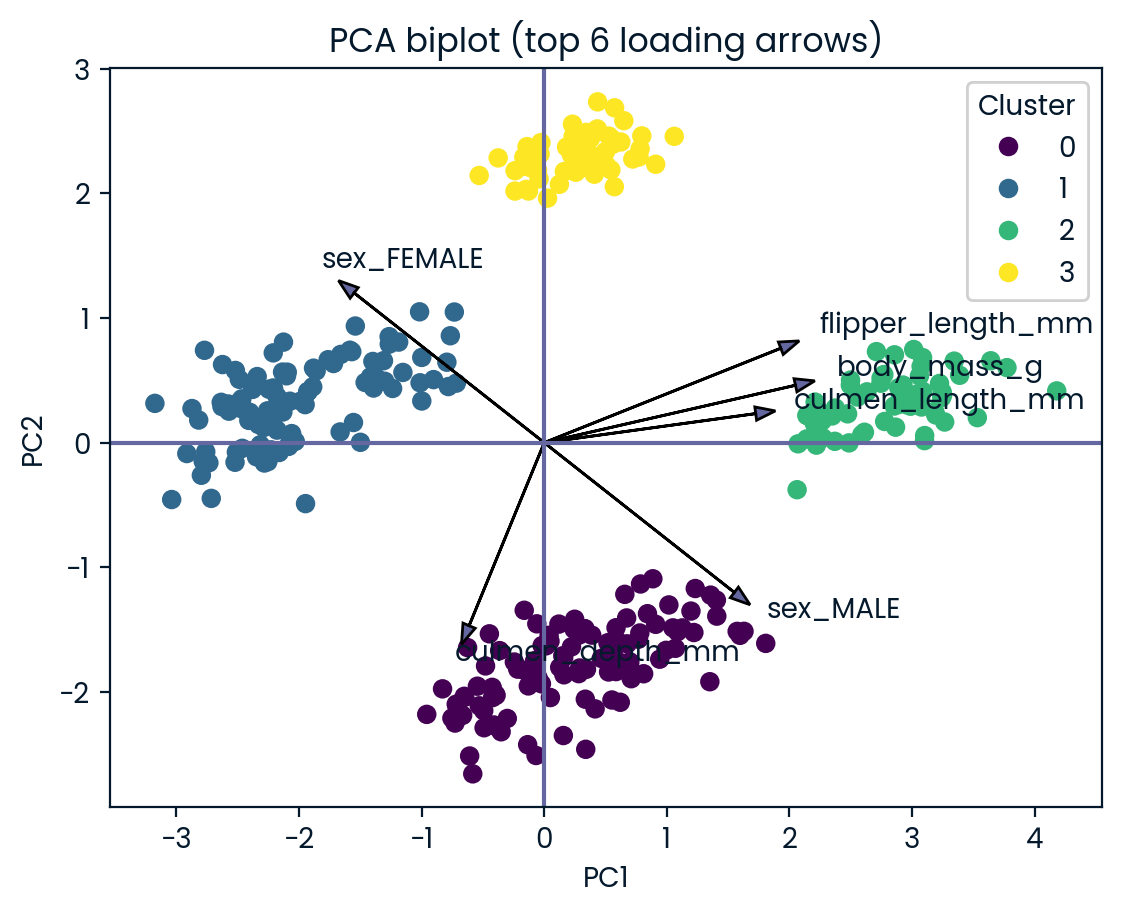

In [60]:
import numpy as np

# Normalize loading per component
loadings = pca.components_.T
norm_loadings = loadings / np.abs(loadings).max(axis=0)
arrow_xy = norm_loadings * np.array([0.3 * x_span, 0.3 * y_span])

# Pick top k features by combined loading magnitude on PC1+PC2
k = 6
strength = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_idx = np.argsort(strength)[-k:]

fig, ax = plt.subplots()

sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_)
plt.axhline(0); plt.axvline(0)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA biplot (top {k} loading arrows)")

legend1 = ax.legend(*sc.legend_elements(), title="Cluster")
ax.add_artist(legend1)

# Add arrows
head_w = 0.02 * min(x_span, y_span)
for i in top_idx:
    dx, dy = arrow_xy[i, 0], arrow_xy[i, 1]
    plt.arrow(0, 0, dx, dy, head_width=head_w, length_includes_head=True)
    plt.text(dx * 1.08, dy * 1.08, feature_names[i])

plt.show()

Based on where the clusters sit relatively to the plot:
- **Cluster 0 - Purple (bottom):** aligned with sex_MALE and partly with culmen_depth → **“male-leaning / deeper-culmen group”**
- **Cluster 1 - Blue (left):** negative PC1 → **“smaller penguins”** (and somewhat toward female compared to the bottom group)
- **Cluster 2 - Green (right):** high body_mass + flipper_length + culmen_length → **“big penguins”**
- **Cluster 3 - Yellow (top):** high PC2 → strongly aligned with sex_FEMALE → **“female-leaning group”**

# Create a statistical DataFrame for each cluster

In [61]:
# Keep the original metrics
numeric_columns = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# Create the final stat table
stat_penguins = penguins_df.groupby("cluster")[numeric_columns].mean()
stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,43.878302,19.111321,194.764151,4006.603774
1,40.217757,17.611215,189.046729,3419.158879
2,49.473770,15.718033,221.540984,5484.836066
3,45.563793,14.237931,212.706897,4679.741379


Based on the summary table, we see that the data match with what we found earlier using PCA biplot:

**Cluster 0 = medium-sized, but deepest beaks**
- Body mass ~4007 g, flippers length ~194.8 mm
- Deepest culmen depth (~19.11 mm) of all clusters
→ This cluster is characterized more by beak depth than pure size.

**Cluster 1 = smallest penguins**
- Lowest body mass (~3419 g)
- Shortest flippers (~189 mm)
- Shorter culmen length (~40.2 mm)
→ This cluster matches the “smaller penguins” group in the PCA biplot.

**Cluster 2 = largest penguins**
- Highest body mass (~5485 g)
- Longest flippers (~221.5 mm)
- Longest culmen length (~49.5 mm)
→ This cluster matches the "big penguins" group in the PCA biplot.

**Cluster 3 = large, but not as extreme as cluster 2**
- Body mass ~4680 g, flippers ~212.7 mm
- Culmen depth is the shallowest (~14.24 mm)
→ Still big, but with notably shallower beaks.